In [34]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


## Section 1


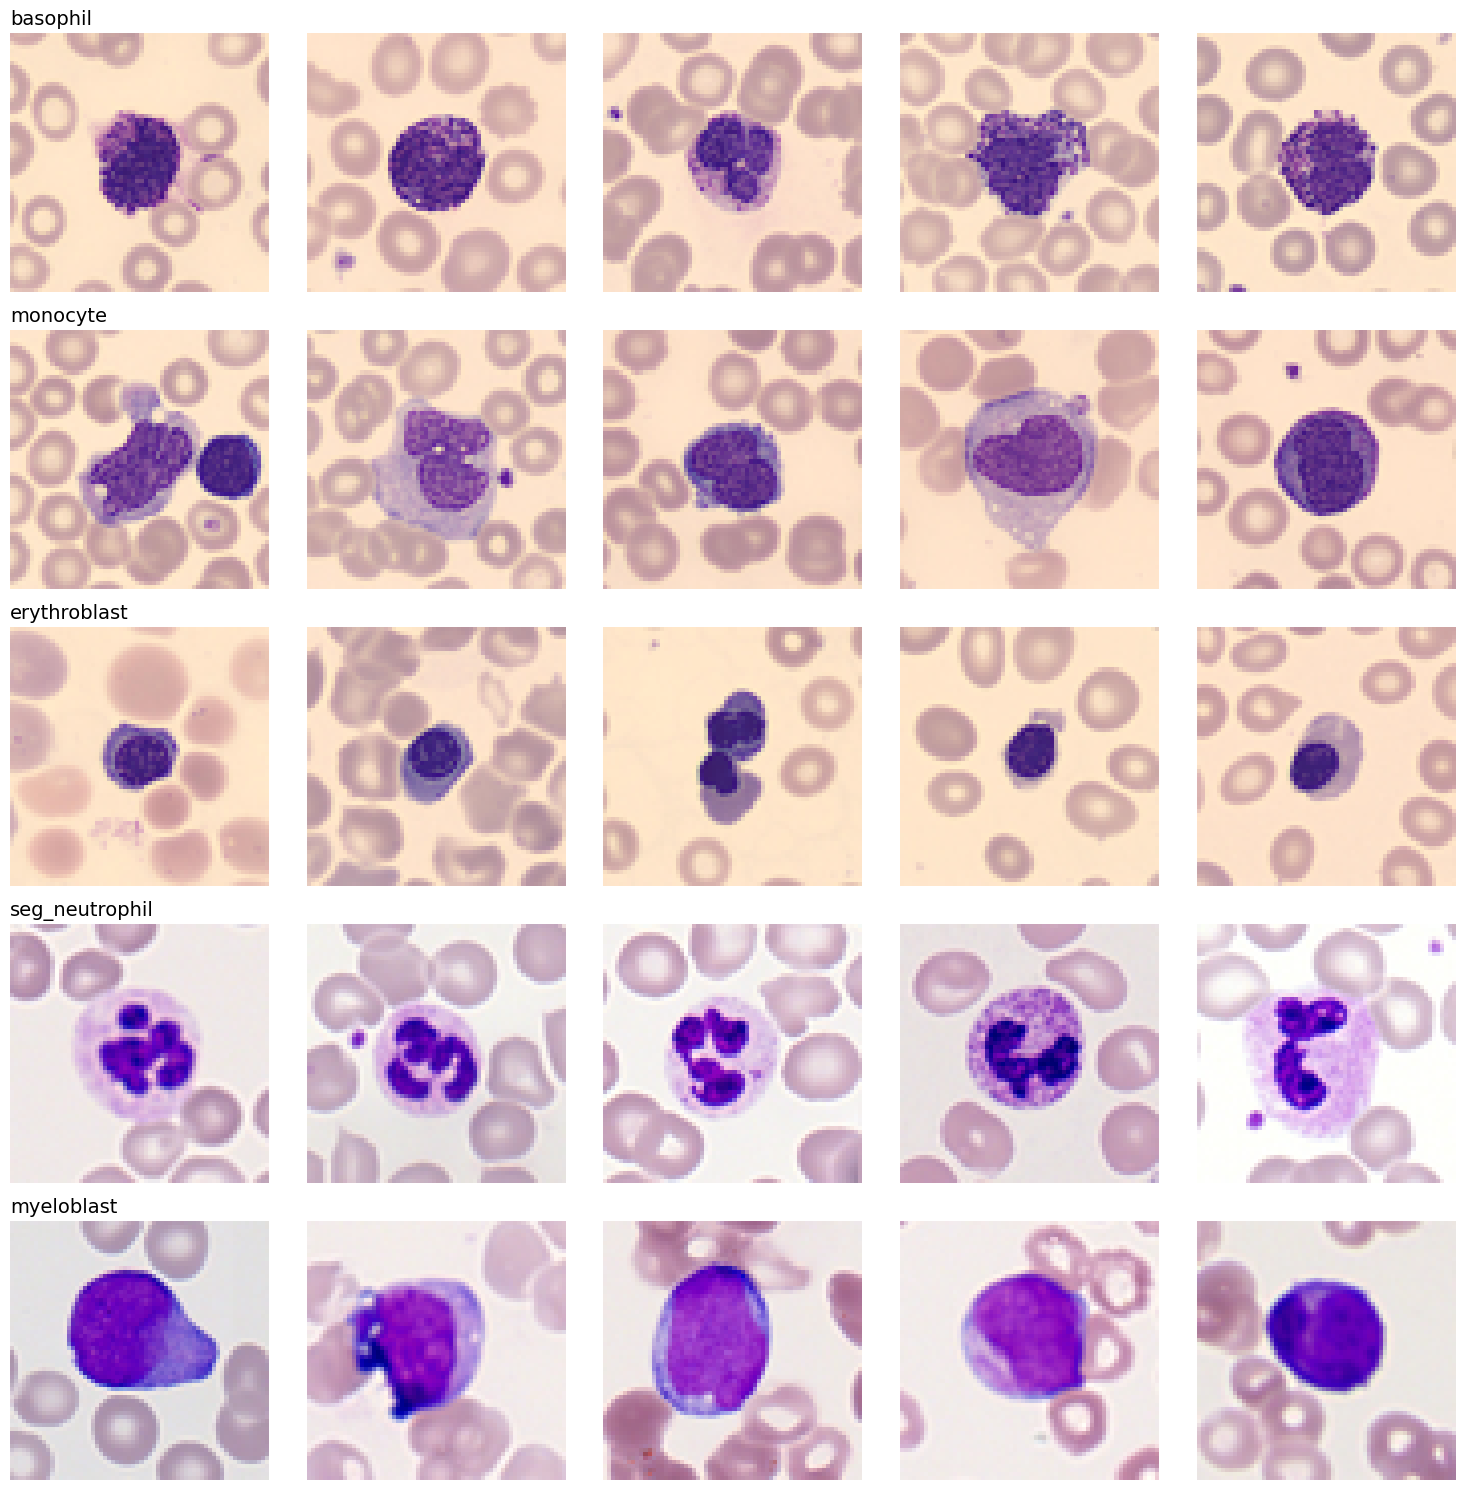

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

DATA_DIR = "./dataset" 
def show_random_images_before_norm(data_dir, samples_per_class=5):
    classes = os.listdir(data_dir)
    classes = [c for c in classes if not c.startswith('.')] 
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, 3 * len(classes)))
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        all_images = os.listdir(cls_path)
        random_images = random.sample(all_images, samples_per_class)
        for j, img_name in enumerate(random_images):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            img = img.resize((64, 64)) 
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(cls, fontsize=14, loc='left')
    
    plt.tight_layout()
    plt.show()

show_random_images_before_norm(DATA_DIR)
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),     
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
])
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=data_transforms)
total_size = len(full_dataset) 
train_size = int(0.8 * total_size) 
test_size = total_size - train_size 
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)




### 1. The Importance of Data Normalization in Deep Neural Networks

In neural networks, the Gradient Descent algorithm aims to minimize the loss function $L(\theta)$ using the update rule $\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$, where $\eta$ is the learning rate.

*   **Without Normalization:** Input features may have vastly different scales (e.g., one pixel is 255, another is 0). This discrepancy causes the loss surface to become highly elongated and elliptical. Consequently, the Gradient Descent algorithm oscillates heavily along dimensions with larger scales and moves very slowly along others, leading to slow convergence or getting trapped in local minima.
*   **With Normalization:** The loss surface becomes much more symmetrical (spherical). This symmetry allows Gradient Descent to move directly and swiftly toward the optimal point. Furthermore, in deep networks, normalized inputs help prevent numerical instabilities such as Vanishing Gradients.

---

### 2. Why DataLoader? Advantages over Dataset

The `Dataset` class in PyTorch is an abstract structure responsible only for knowing the total size of the data (`__len__`) and retrieving a specific sample with its label (`__getitem__`).

Modern neural networks are not trained sample-by-sample; they use Mini-batch Stochastic Gradient Descent. The `DataLoader` acts as a wrapper around the `Dataset` to optimize this process by providing:

*   **Batching:** GPUs are designed for highly parallel matrix operations. Feeding data in batches (e.g., a tensor of shape $B \times C \times H \times W$, where $B$ is the batch size) maximizes GPU utilization. `Dataset` alone cannot group data.
*   **Shuffling:** To prevent the network from memorizing the order of the data (overfitting to the sequence), the `DataLoader` randomly shuffles the dataset every epoch. This introduces useful stochastic noise that helps the optimizer escape local minima.
*   **Multiprocessing:** Using the `num_workers` parameter, `DataLoader` utilizes multiple CPU cores to load and preprocess data from the disk concurrently. This ensures the GPU never stays idle waiting for data (preventing an $I/O$ bottleneck).

---

### 3. Displaying 5 Random Images per Class Before Normalization

This step serves as a **Sanity Check** in Computer Vision projects. 

Before converting pixel values from raw integers (0 to 255) to normalized floating-point numbers (often between -1 and 1), we plot them to visually confirm that:
1. The images are loaded correctly and are intact.
2. The labels are accurately mapped to the correct visual classes.

We do this *before* normalization because normalized images often look dark, washed out, or have unnatural colors to the human eye, making visual verification difficult.


In [7]:
import torch
import torch.nn as nn
class BloodCellMLP(nn.Module):
    def __init__(self):
        super(BloodCellMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 64 * 3, 256), 
            nn.ReLU(),
            nn.Dropout(p=0.5),         
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 5)            
        )
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x


In [ ]:
import torch.optim as optim
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = BloodCellMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}") 


Using device: mps
Total trainable parameters: 3,179,525


In [8]:
epochs = 80
train_losses = []
test_losses = []
for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * images.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * images.size(0)
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")


Epoch [1/80] | Train Loss: 1.0088 | Test Loss: 0.5460
Epoch [2/80] | Train Loss: 0.7346 | Test Loss: 0.5653
Epoch [3/80] | Train Loss: 0.6774 | Test Loss: 0.6214
Epoch [4/80] | Train Loss: 0.6865 | Test Loss: 0.5096
Epoch [5/80] | Train Loss: 0.6303 | Test Loss: 0.5131
Epoch [6/80] | Train Loss: 0.6329 | Test Loss: 0.4621
Epoch [7/80] | Train Loss: 0.6259 | Test Loss: 0.5249
Epoch [8/80] | Train Loss: 0.6052 | Test Loss: 0.4110
Epoch [9/80] | Train Loss: 0.6081 | Test Loss: 0.4970
Epoch [10/80] | Train Loss: 0.5592 | Test Loss: 0.4308
Epoch [11/80] | Train Loss: 0.5602 | Test Loss: 0.4430
Epoch [12/80] | Train Loss: 0.5309 | Test Loss: 0.4428
Epoch [13/80] | Train Loss: 0.5289 | Test Loss: 0.5216
Epoch [14/80] | Train Loss: 0.5340 | Test Loss: 0.3641
Epoch [15/80] | Train Loss: 0.5076 | Test Loss: 0.3713
Epoch [16/80] | Train Loss: 0.5086 | Test Loss: 0.3571
Epoch [17/80] | Train Loss: 0.4830 | Test Loss: 0.3517
Epoch [18/80] | Train Loss: 0.4905 | Test Loss: 0.4468
Epoch [19/80] | Tra

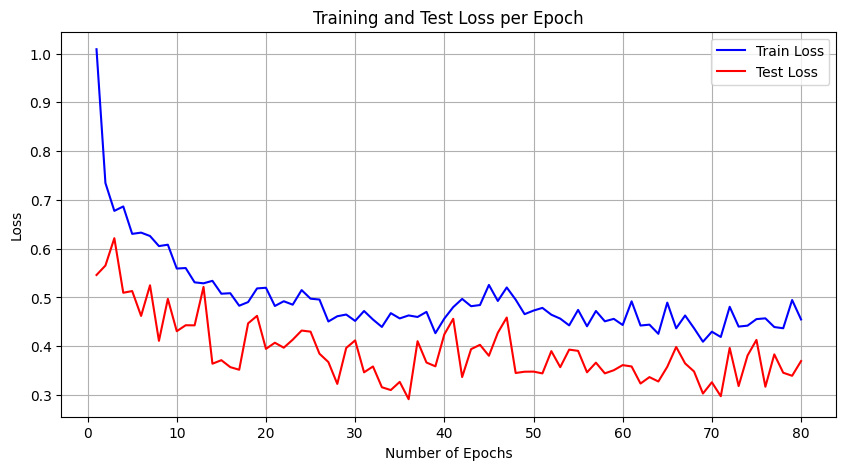

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', color='red')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       199
           1       0.98      0.88      0.93       199
           2       0.91      0.79      0.84       197
           3       0.97      0.80      0.88       188
           4       0.80      0.98      0.88       217

    accuracy                           0.87      1000
   macro avg       0.89      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000



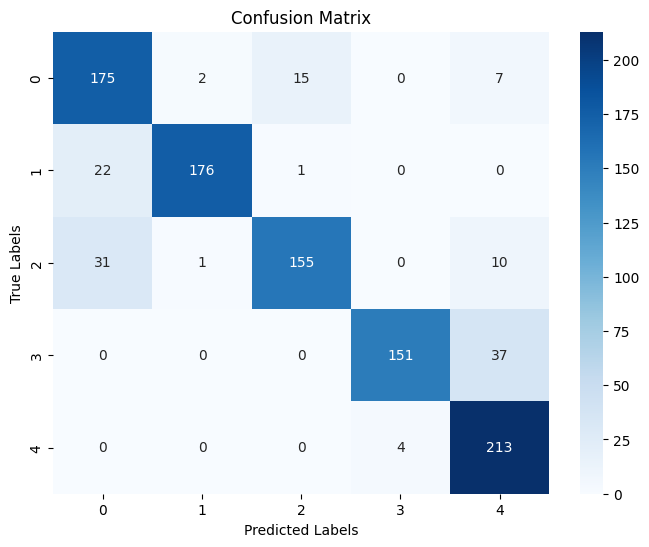

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()




### 1. The Mechanism of Dropout and Its Effect on the Model
**How it works:** Dropout is a regularization technique used in neural networks to prevent overfitting. During the training phase, it randomly "drops out" (i.e., sets to zero) a proportion of neurons in a layer with a specified probability $p$ (e.g., $p=0.5$ and $p=0.3$ in our model). In each forward pass, a different set of neurons is deactivated. During the evaluation/testing phase (`model.eval()`), Dropout is disabled, and all neurons are used, but their weights are scaled down by $1-p$ to account for the active neurons during training (PyTorch handles this scaling internally).
**Effect on the model:** By randomly disabling neurons, Dropout prevents complex co-adaptations on training data. It forces the network to learn more robust and generalized features rather than relying on specific paths or individual neurons, effectively acting as an ensemble of multiple sub-networks.

### 2. Manual Calculation of Model Parameters
The model is a Multi-Layer Perceptron (MLP) consisting of fully connected (`Linear`) layers. The input image size is $64 \times 64 \times 3$, which gets flattened to $12,288$ features. The formula for parameters in a Linear layer is: $\text{Parameters} = (\text{Input\_Features} \times \text{Output\_Features}) + \text{Biases}$.

*   **Layer 1 (`Linear(12288, 256)`):**
    *   Weights: $12288 \times 256 = 3,145,728$
    *   Biases: $256$
    *   Total for Layer 1 = $3,145,984$
*   **Layer 2 (`Linear(256, 128)`):**
    *   Weights: $256 \times 128 = 32,768$
    *   Biases: $128$
    *   Total for Layer 2 = $32,896$
*   **Layer 3 (`Linear(128, 5)`):**
    *   Weights: $128 \times 5 = 640$
    *   Biases: $5$
    *   Total for Layer 3 = $645$

**Total Parameters:** $$3,145,984 + 32,896 + 645 = 3,179,525$$
**Comparison:** The manually calculated total ($3,179,525$) matches exactly with the output generated by the notebook's code `sum(p.numel() for p in model.parameters())`.

### 3. Cross-Entropy Loss and Its Suitability
**Concept:** Cross-Entropy (CE) loss measures the performance of a classification model whose output is a probability value between 0 and 1. It quantifies the difference between the true probability distribution (one-hot encoded labels) and the predicted probability distribution. The mathematical formula is:
$$\text{CE} = -\sum_{i=1}^{C} t_i \log(p_i)$$
where $C$ is the number of classes, $t_i$ is the true label (0 or 1), and $p_i$ is the Softmax probability for the $i$-th class.
**Why use it here?** The nature of this problem is **Multi-Class Classification** (classifying blood cells into 5 distinct, mutually exclusive categories). PyTorch's `nn.CrossEntropyLoss` combines `nn.LogSoftmax` and `nn.NLLLoss` (Negative Log Likelihood Loss) in a single class. It penalizes the model heavily when it is highly confident in an incorrect prediction, making it the standard and most effective loss function for multi-class classification tasks.

### 4. Adam Optimizer vs. SGD
**Adam (Adaptive Moment Estimation):** Adam is an optimization algorithm that computes adaptive learning rates for each parameter. It keeps track of both the exponentially decaying average of past gradients (first moment, like momentum) and the exponentially decaying average of past squared gradients (second moment, like RMSprop).
**Main Differences from SGD (Stochastic Gradient Descent):**
*   **Learning Rate:** Standard SGD uses a single, fixed learning rate for all parameters. Adam dynamically adapts the learning rate for each weight individually.
*   **Convergence Speed:** Due to its adaptive nature and momentum, Adam typically converges much faster than basic SGD, especially in complex landscapes.
*   **Sparsity:** Adam handles sparse gradients better and requires less manual hyperparameter tuning (like finding the exact optimal initial learning rate) compared to SGD.

### 5. Analysis of the Loss Curve and Overfitting
**Analysis of the Curve:** Looking at the plotted loss curve, both Train Loss and Test Loss decrease rapidly in the initial epochs and then stabilize. A highly notable observation is that the **Test Loss is consistently lower than the Train Loss**.
**Did overfitting occur?** No, overfitting did not occur. If the model were overfitting, the Test Loss would eventually start to increase while the Train Loss continued to decrease, creating a widening gap between the two curves. Here, both curves remain relatively stable without diverging.
**How can this specific behavior be understood?** The phenomenon where Test Loss is lower than Train Loss is heavily attributed to the use of **Dropout**.
1.  **During Training:** `model.train()` is active. Dropout zeroes out 50% of neurons in the first hidden layer and 30% in the second. This artificially restricts the model's capacity and makes predictions harder, resulting in a higher training loss.
2.  **During Evaluation (Testing):** `model.eval()` is active. Dropout is turned off, and the model utilizes its full capacity (all neurons) to make predictions. Consequently, the network performs better, yielding a lower test loss compared to the artificially hindered training phase.

## Section 2


In [11]:
import torch
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) 
        )
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 380),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(380, 5)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x
cnn_model = CNN()
total_cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters in CNN: {total_cnn_params:,}") 

Total trainable parameters in CNN: 3,208,493


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [15]:

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
cnn_model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
epochs = 80
train_losses = []
test_losses = []
print("Starting training for 80 epochs...")
for epoch in range(epochs):
    cnn_model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    cnn_model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
            
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

Using device: mps
Starting training for 80 epochs...
Epoch [1/80] | Train Loss: 0.6221 | Test Loss: 0.3334
Epoch [10/80] | Train Loss: 0.0289 | Test Loss: 0.0717
Epoch [20/80] | Train Loss: 0.0099 | Test Loss: 0.0508
Epoch [30/80] | Train Loss: 0.0004 | Test Loss: 0.0694
Epoch [40/80] | Train Loss: 0.0073 | Test Loss: 0.0941
Epoch [50/80] | Train Loss: 0.0068 | Test Loss: 0.1018
Epoch [60/80] | Train Loss: 0.0232 | Test Loss: 0.1874
Epoch [70/80] | Train Loss: 0.0001 | Test Loss: 0.1149
Epoch [80/80] | Train Loss: 0.0002 | Test Loss: 0.0840


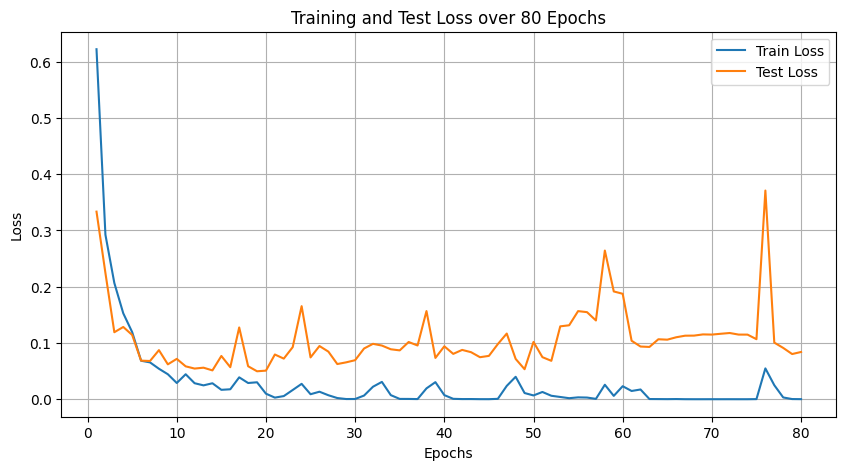

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss over 80 Epochs')
plt.legend()
plt.grid(True)
plt.show()


--- Classification Report ---
                precision    recall  f1-score   support

      basophil       0.99      0.98      0.98       199
  erythroblast       1.00      0.98      0.99       199
      monocyte       0.97      0.99      0.98       197
    myeloblast       1.00      0.99      1.00       188
seg_neutrophil       0.99      1.00      1.00       217

      accuracy                           0.99      1000
     macro avg       0.99      0.99      0.99      1000
  weighted avg       0.99      0.99      0.99      1000


--- Confusion Matrix ---


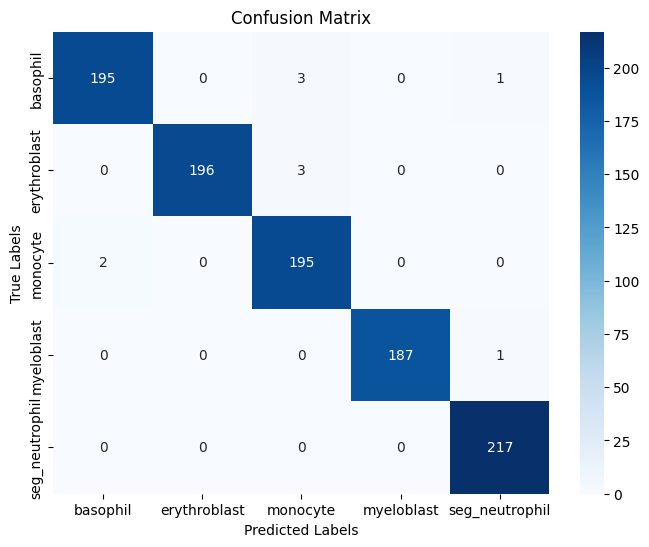

In [17]:
cnn_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("\n--- Classification Report ---")
target_names = test_loader.dataset.dataset.classes 
print(classification_report(all_labels, all_preds, target_names=target_names))
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()




### 1. The Impact of Kernel Size in Convolutional Networks

**General Impact on Feature Extraction:**
The kernel size (or filter size) determines the "Receptive Field" of the convolutional layer—meaning how much spatial context the network looks at simultaneously. It dictates the scale of the patterns the network can detect in a single operation. 

**Smaller Kernels (e.g., $3 \times 3$ - used in your model) vs. Larger Kernels (e.g., $7 \times 7$ or $11 \times 11$):**

*   **Local Feature Recognition:**
    *   **Smaller Kernels:** Highly effective at extracting fine-grained, highly localized features such as sharp edges, corners, and small textures (e.g., the granules in a basophil or the exact boundary of a cell nucleus).
    *   **Larger Kernels:** Better at capturing broad, global structural information but tend to blur or completely miss fine local details.
*   **Computational Load and Parameters:**
    *   **Advantage of Smaller Kernels:** Using smaller kernels significantly reduces the computational load and the number of parameters. For instance, a single $5 \times 5$ kernel has $25$ parameters. Stacking two $3 \times 3$ kernels achieves the exact same receptive field ($5 \times 5$) but requires only $3 \times 3 + 3 \times 3 = 18$ parameters. 
    *   Furthermore, stacking multiple small kernels allows the network to insert activation functions (like `ReLU`) between them, introducing more non-linearity and allowing the model to learn more complex decision boundaries without increasing the computational burden. Your model perfectly utilizes this standard practice by using `kernel_size=3` throughout its convolutional blocks.

---

### 2. The Impact of Network Depth (Number of Sequential Conv Layers)

**Learning Capacity and Abstract Features:**
Increasing the depth of a network fundamentally increases its learning capacity. Deep networks build a hierarchical representation of data. 
*   **Early layers** (like your first `Conv2d` with 32 channels) learn basic, low-level features (edges, colors). 
*   **Deeper layers** (like your third `Conv2d` with 128 channels) combine these basic features to understand highly complex and abstract representations (e.g., the complete shape of a specific white blood cell).

**Does making the network deeper always improve accuracy?**
**No.** While depth is powerful, arbitrarily stacking more layers eventually leads to a degradation in performance. For a dataset of size $64 \times 64$, your current 3-block architecture is already optimal (achieving 99% accuracy). Making it significantly deeper could introduce severe problems:

*   **The Vanishing Gradient Problem:** During backpropagation, gradients are calculated using the chain rule. In extremely deep networks, if the gradients are smaller than 1, multiplying them repeatedly across dozens of layers causes the gradient to become exponentially small (vanish) by the time it reaches the early layers. Consequently, the initial layers stop learning. (While `ReLU` activation helps mitigate this compared to `Sigmoid`, it is still a major issue in very deep, plain networks without residual connections/ResNets).
*   **Overfitting:** A deeper network contains millions of additional parameters. If the complexity of the model drastically exceeds the complexity of the dataset (or if the dataset is too small), the network will simply memorize the training data rather than generalizing. This leads to a scenario where the training loss drops to zero, but the test/validation loss spikes heavily. Looking at your training logs, your current CNN has $\approx 3.2$ million parameters and already reaches a training loss of $0.0001$; adding more depth would only push it toward overfitting without any real-world accuracy gain.

## Section 3


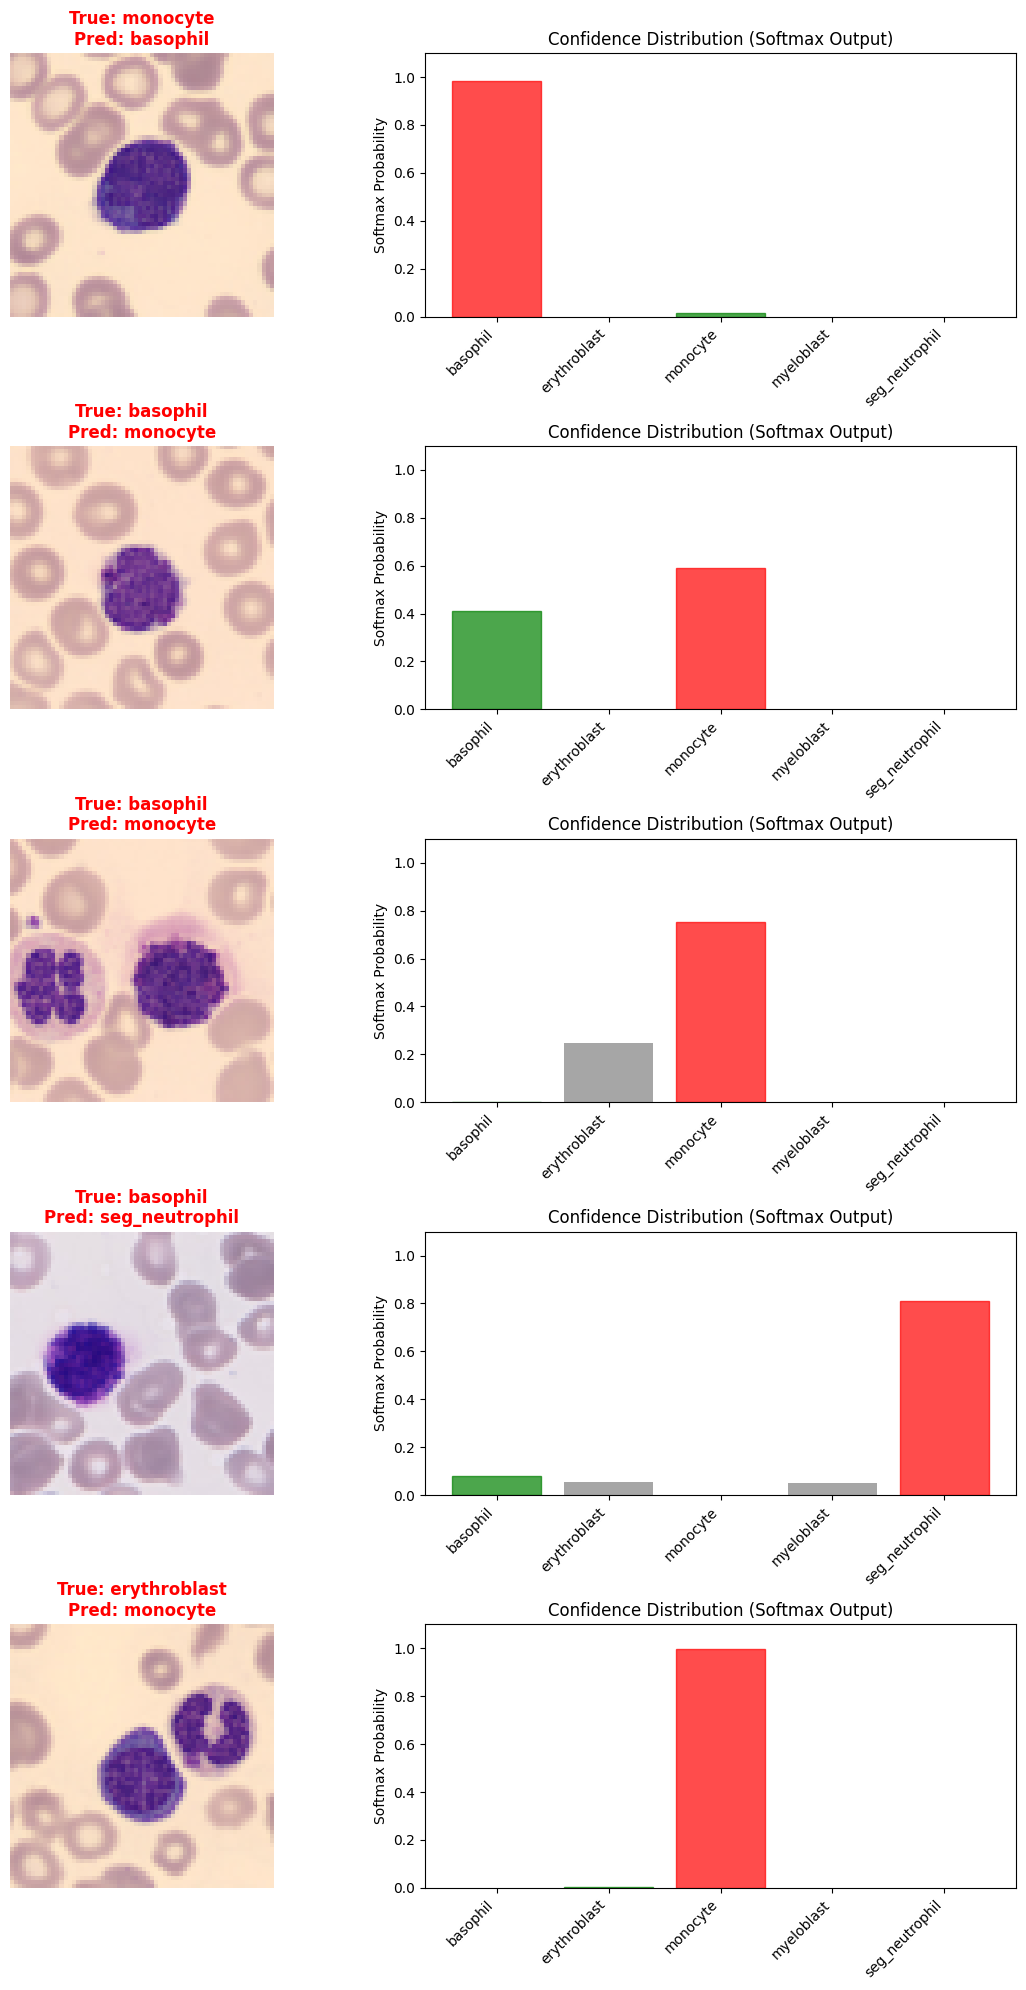

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def analyze_model_errors(model, dataloader, class_names, device, num_samples=5):
    model.eval()
    misclassified_images = []
    true_labels = []
    pred_labels = []
    softmax_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            incorrect_mask = preds != labels
            incorrect_idx = incorrect_mask.nonzero(as_tuple=True)[0]

            for idx in incorrect_idx:
                misclassified_images.append(inputs[idx].cpu())
                true_labels.append(labels[idx].item())
                pred_labels.append(preds[idx].item())
                softmax_probs.append(probs[idx].cpu().numpy())

                if len(misclassified_images) >= num_samples:
                    break
            if len(misclassified_images) >= num_samples:
                break

    if len(misclassified_images) == 0:
        return

    fig, axes = plt.subplots(len(misclassified_images), 2, figsize=(12, 4 * len(misclassified_images)))
    if len(misclassified_images) == 1: axes = [axes] 

    def unnormalize(img):
        img = img * 0.5 + 0.5 
        img = img.clamp(0, 1)
        return img.permute(1, 2, 0).numpy()

    for i in range(len(misclassified_images)):
        ax_img = axes[i][0]
        img_np = unnormalize(misclassified_images[i])
        ax_img.imshow(img_np)
        ax_img.axis('off')
        ax_img.set_title(f"True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}", 
                         color='red', fontweight='bold')

        ax_bar = axes[i][1]
        y_pos = np.arange(len(class_names))

        bars = ax_bar.bar(y_pos, softmax_probs[i], align='center', alpha=0.7, color='gray')
        bars[pred_labels[i]].set_color('red')
        bars[true_labels[i]].set_color('green')
        
        ax_bar.set_xticks(y_pos)
        ax_bar.set_xticklabels(class_names, rotation=45, ha="right")
        ax_bar.set_ylabel('Softmax Probability')
        ax_bar.set_title('Confidence Distribution (Softmax Output)')
        ax_bar.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()
class_names = test_dataset.dataset.classes
analyze_model_errors(cnn_model, test_loader, class_names, device, num_samples=5)


Here is a detailed and analytical response in English addressing the two questions based on the provided code output and error visualizations. You can use this directly in your notebook.

***

### 1. Analysis of Probability Distributions (Softmax Outputs) in Misclassifications

By analyzing the bar charts representing the softmax confidence scores, we can observe that the network exhibits a mix of behaviors, but notably suffers from **overconfidence in incorrect predictions**. 

*   **High Certainty (Overconfident) Errors:** In the majority of the shown misclassifications (specifically rows 1, 4, and 5), the model makes the wrong prediction with very high confidence (probabilities exceeding $0.8$ or even approaching $1.0$). For example, in the first sample (True: `monocyte`, Pred: `basophil`), the red bar shows almost $100\%$ certainty for the wrong class. This indicates that the network has strongly latched onto specific visual features (perhaps a specific color or texture artifact) that it heavily associates with the incorrect class, completely ignoring the true class features.
*   **Divided Probabilities (Uncertainty):** There are also instances where the network is genuinely confused and splits its probability mass. In row 2 (True: `basophil`, Pred: `monocyte`), the network is uncertain, assigning approximately $0.6$ probability to `monocyte` and $0.4$ to `basophil`. This happens when the visual features of the cell genuinely straddle the boundary between two learned class representations.

**Conclusion:** While the model occasionally shows uncertainty, the prevalence of high-confidence errors suggests that the model is somewhat overfitted to certain local features (like specific color blobs or granular textures) rather than capturing the robust, holistic structural geometry of the cells. 

---

### 2. Visual Similarities and Features Causing Network Deception

Looking at the misclassified images, blood cell classification is inherently challenging due to high inter-class visual similarities and intra-class variance. The network is likely being deceived by the following shared visual features and anomalies:

*   **Similar Nuclear Morphologies and Textures (`Basophil` vs. `Monocyte`):** 
    *   Basophils are typically characterized by coarse, dark purple granules that often obscure the nucleus. 
    *   Monocytes usually have a large, irregularly shaped (often kidney-shaped) nucleus. 
    *   In **Row 1**, the monocyte has a very dense, round, and slightly granular-looking nucleus, causing the network to confuse its texture with a basophil. Conversely, in **Row 2**, the basophil's granules form a solid, large dark mass that the network likely mistook for the large, singular nucleus of a monocyte.
*   **Pseudo-Segmentation (`Basophil` vs. `Seg_neutrophil`):** Segmented neutrophils are defined by their multi-lobed nuclei connected by thin threads. In **Row 4**, the true basophil has a somewhat irregular or clumpy appearance that visually mimics the disconnected, lobed structure of a segmented neutrophil, tricking the network's shape detectors.
*   **Presence of Multiple Cells/Distractors in the Field of View:** In **Rows 3 and 5**, the bounding box contains more than one main cell (or a main cell and a prominent fragment). Standard CNN classifiers without explicit attention mechanisms or bounding box regression often struggle here. The network extracts features globally and might be classifying the *adjacent* cell or a combination of both cells' features, leading to completely misguided, high-confidence errors (like predicting `monocyte` in row 5 due to the combined bulk of the two separate erythroblast nuclei).

## Section 4
 

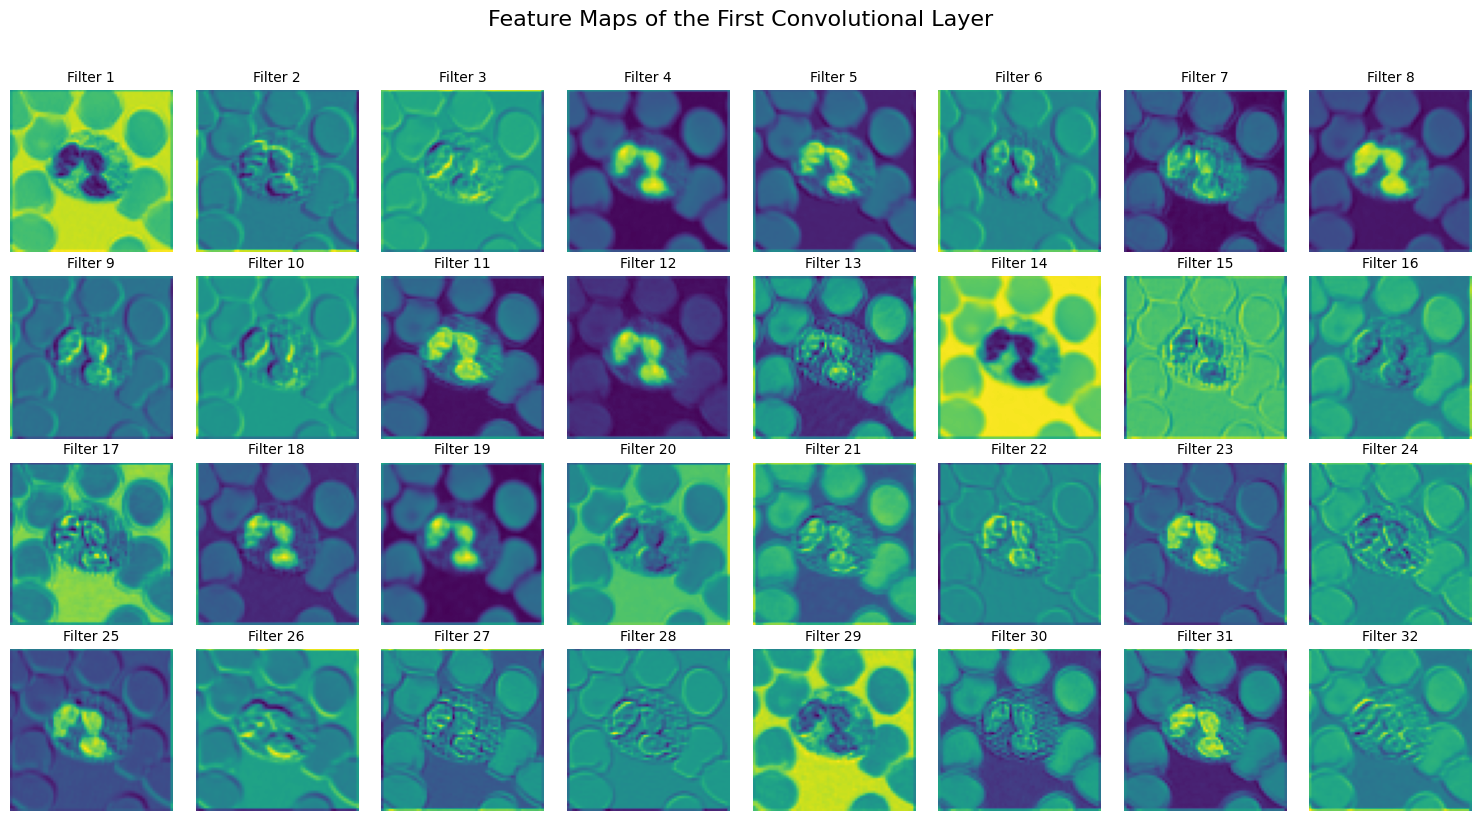

In [28]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

def visualize_first_layer_feature_maps(model, dataloader, device):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    single_image = images[0].unsqueeze(0).to(device) 

    first_conv_layer = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            first_conv_layer = module
            break
            
    if first_conv_layer is None:
        return


    model.eval()
    with torch.no_grad():
        feature_maps = first_conv_layer(single_image)
        
    feature_maps = feature_maps.squeeze(0).cpu().numpy()
    num_filters = feature_maps.shape[0]

    cols = 8
    rows = (num_filters + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 2 * rows))
    axes = axes.flatten()

    for i in range(num_filters):
        axes[i].imshow(feature_maps[i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Filter {i+1}', fontsize=10)

    for j in range(num_filters, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Feature Maps of the First Convolutional Layer", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

visualize_first_layer_feature_maps(cnn_model, test_loader, device)


## Section 5

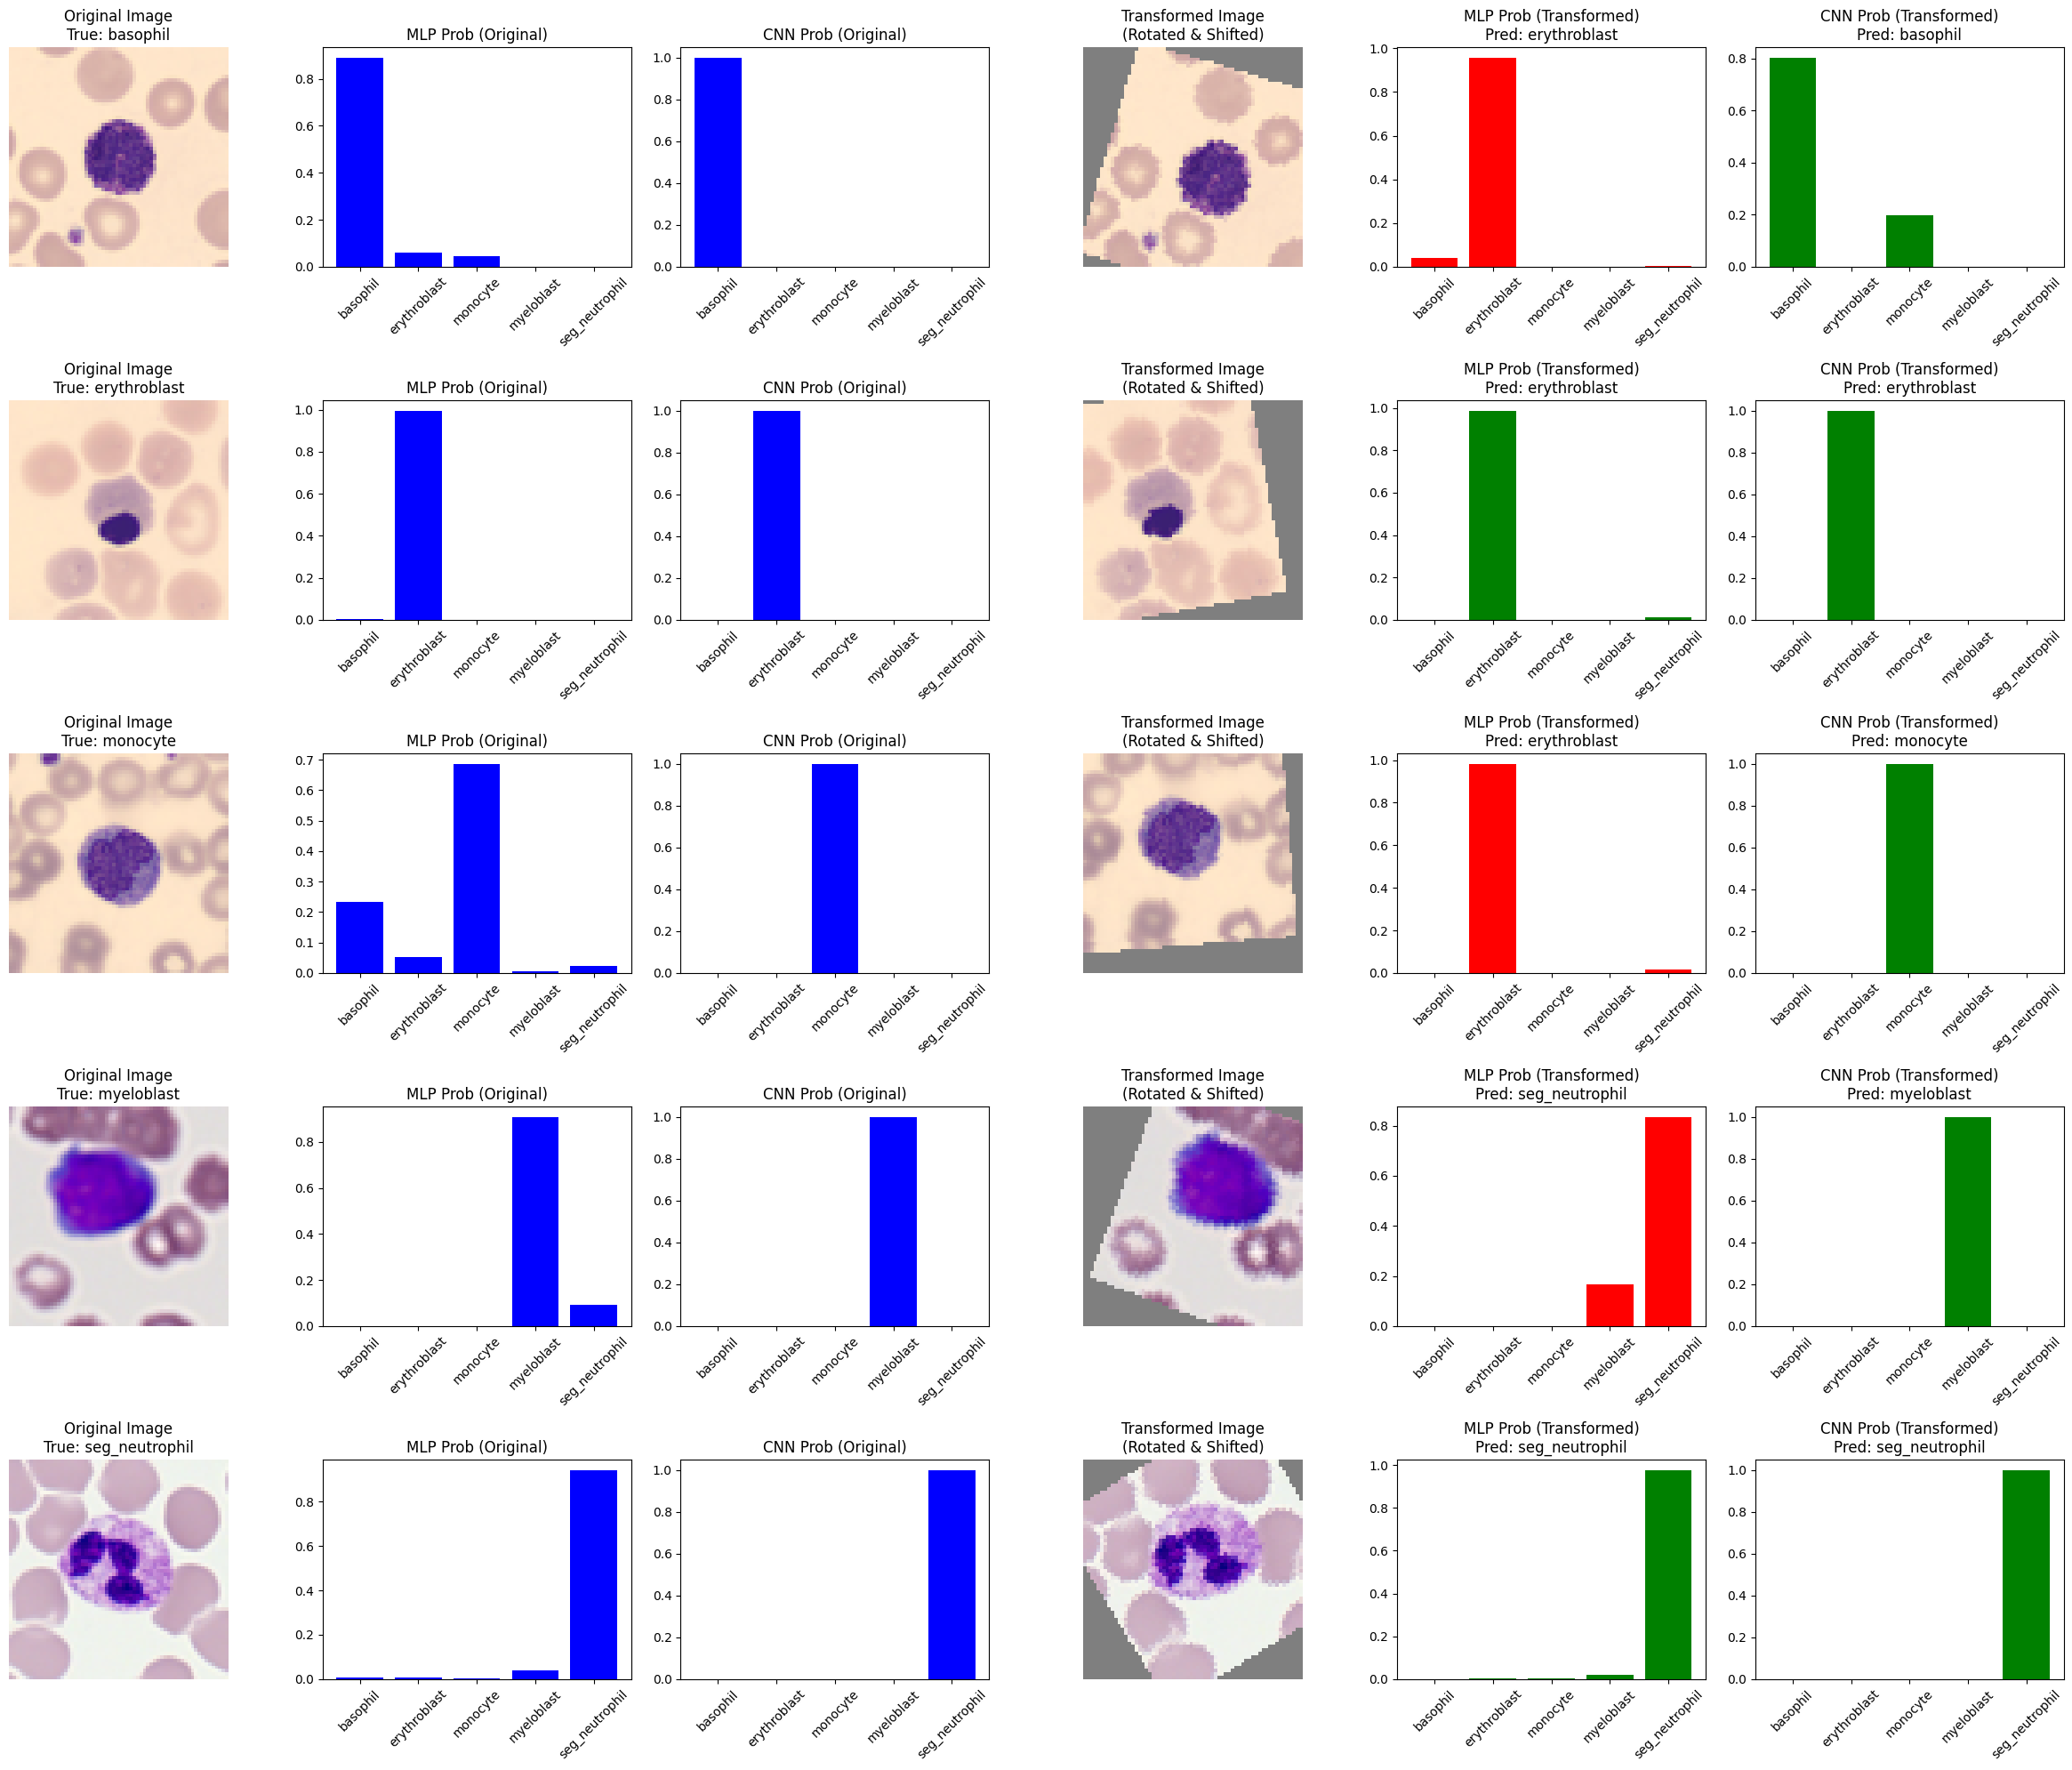

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

def test_spatial_invariance(mlp_model, cnn_model, dataloader, classes, device):

    mlp_model.eval()
    cnn_model.eval()

    selected_images = {} 

    with torch.no_grad():
        for images, labels in dataloader:
            images_device = images.to(device)
            labels_device = labels.to(device)
            
            mlp_outputs = mlp_model(images_device)
            cnn_outputs = cnn_model(images_device)
            
            _, mlp_preds = torch.max(mlp_outputs, 1)
            _, cnn_preds = torch.max(cnn_outputs, 1)
            
            for i in range(len(labels)):
                label_idx = labels[i].item()
                if label_idx not in selected_images:
                    if mlp_preds[i] == label_idx and cnn_preds[i] == label_idx:
                        selected_images[label_idx] = (images[i].cpu(), label_idx)
                if len(selected_images) == len(classes):
                    break
            if len(selected_images) == len(classes):
                break

    if len(selected_images) < len(classes):
        print(f"هشدار: فقط برای {len(selected_images)} کلاس نمونه مناسب یافت شد.")
    spatial_transform = transforms.RandomAffine(degrees=45, translate=(0.2, 0.2))
    def unnormalize(img_tensor):
        img_tensor = img_tensor / 2 + 0.5  
        npimg = img_tensor.numpy()
        return np.clip(np.transpose(npimg, (1, 2, 0)), 0, 1)
    num_samples = len(selected_images)
    fig, axes = plt.subplots(num_samples, 6, figsize=(24, 4 * num_samples))
    
    for row, class_idx in enumerate(sorted(selected_images.keys())):
        orig_img, label = selected_images[class_idx]

        trans_img = spatial_transform(orig_img)

        orig_input = orig_img.unsqueeze(0).to(device)
        trans_input = trans_img.unsqueeze(0).to(device)

        with torch.no_grad():
            mlp_orig_prob = F.softmax(mlp_model(orig_input), dim=1).squeeze().cpu().numpy()
            cnn_orig_prob = F.softmax(cnn_model(orig_input), dim=1).squeeze().cpu().numpy()
            
            mlp_trans_prob = F.softmax(mlp_model(trans_input), dim=1).squeeze().cpu().numpy()
            cnn_trans_prob = F.softmax(cnn_model(trans_input), dim=1).squeeze().cpu().numpy()

        axes[row, 0].imshow(unnormalize(orig_img))
        axes[row, 0].set_title(f"Original Image\nTrue: {classes[label]}")
        axes[row, 0].axis('off')

        axes[row, 1].bar(classes, mlp_orig_prob, color='blue')
        axes[row, 1].set_title("MLP Prob (Original)")
        axes[row, 1].tick_params(axis='x', rotation=45)

        axes[row, 2].bar(classes, cnn_orig_prob, color='blue')
        axes[row, 2].set_title("CNN Prob (Original)")
        axes[row, 2].tick_params(axis='x', rotation=45)

        axes[row, 3].imshow(unnormalize(trans_img))
        axes[row, 3].set_title("Transformed Image\n(Rotated & Shifted)")
        axes[row, 3].axis('off')

        mlp_pred_idx = np.argmax(mlp_trans_prob)
        mlp_color = 'green' if mlp_pred_idx == label else 'red'
        axes[row, 4].bar(classes, mlp_trans_prob, color=mlp_color)
        axes[row, 4].set_title(f"MLP Prob (Transformed)\nPred: {classes[mlp_pred_idx]}")
        axes[row, 4].tick_params(axis='x', rotation=45)

        cnn_pred_idx = np.argmax(cnn_trans_prob)
        cnn_color = 'green' if cnn_pred_idx == label else 'red'
        axes[row, 5].bar(classes, cnn_trans_prob, color=cnn_color)
        axes[row, 5].set_title(f"CNN Prob (Transformed)\nPred: {classes[cnn_pred_idx]}")
        axes[row, 5].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

test_spatial_invariance(model, cnn_model, test_loader, train_dataset.dataset.classes, device)





### 1. Performance Analysis of MLP and CNN Models Before and After Geometric Transformations

By examining the output charts (Softmax probabilities) provided in the screenshots, a stark difference in the stability of the two models against spatial transformations (translation and rotation) is evident:

*   **Performance Before Transformations (Original Images):** In the second and third columns, both the MLP and CNN models successfully predict the correct class for all $5$ samples (rows 1 to 5) with very high confidence (probabilities close to $1.0$). This indicates that both models have effectively learned the discriminative features of each class under normal, centered conditions.
*   **Performance After Transformations (Rotated and Translated Images):** In the fifth and sixth columns, the impact of the `RandomAffine` transformation becomes crystal clear:
    *   **Severe Performance Drop in MLP:** The Multi-Layer Perceptron completely fails in $3$ out of the $5$ cases (rows 1, 3, and 4). It assigns the transformed images to incorrect classes with high confidence (indicated by the red probability bars). For instance, in the first row, the shifted `basophil` image is misclassified as an `erythroblast` with a probability near $1.0$.
    *   **Stability and Robustness of CNN:** In stark contrast, the Convolutional Neural Network (CNN) successfully maintains its correct prediction across all $5$ samples (indicated by the green probability bars in the last column). Although the confidence level drops slightly in some cases (e.g., row 1), the highest probability mass remains firmly on the correct class.

**Conclusion for Part 1:** The CNN model demonstrated significantly higher stability and robustness against rotation and translation, successfully maintaining its accurate predictions. Meanwhile, the MLP model proved to be highly sensitive and brittle when faced with these spatial perturbations.

---

### 2. Structural and Theoretical Analysis: The Roots of Spatial Invariance in CNNs vs. MLPs

The reason for this drastic difference in performance stems from fundamental architectural differences between the two networks:

*   **MLP's Inability to Comprehend Spatial Structure:** 
    To process an image, MLP networks first flatten the 2D (or 3D colored) image matrix into a 1D vector. In the Fully Connected (FC) layers, every pixel at a specific spatial location is tied to a fixed, distinct weight. Consequently, the network learns rules such as "if there are dark pixel values at indices $100$ to $150$, it is a cell nucleus." 
    If the image is translated or rotated even slightly, those dark values shift to different pixel indices (e.g., $200$ to $250$). Because these new pixel locations correspond to entirely different weights in the network, the MLP fails to recognize the pattern. This model is inherently **location-dependent** and relies on absolute spatial coordinates.

*   **CNN's Inherent Spatial Invariance and Equivariance:**
    Convolutional architectures were explicitly designed to overcome this limitation, drawing inspiration from the biological visual cortex. Two primary mechanisms grant CNNs this stability:
    1.  **Weight Sharing (Convolutional Layers):** Instead of using fixed weights for specific locations, CNNs use filters (kernels) that slide (convolve) across the entire image. A filter trained to detect the "curved edge of a nucleus" will detect that exact feature regardless of whether the nucleus is in the center or at the corner of the image. This allows the network to find local patterns independent of their absolute coordinates, a property known as **Translation Equivariance**.
    2.  **Pooling Layers:** Layers such as Max Pooling downsample the feature maps by selecting the maximum value within a small local region (e.g., a $2 \times 2$ window). If a feature shifts by a few pixels in the input image, the output of the pooling layer often remains identical. This operation introduces **Local Translation Invariance**, allowing the model to be highly robust against minor translations and deformations.

**Final Conclusion:** By utilizing local filters and weight sharing, CNN architectures inherently search for the *presence* of a feature rather than its *exact location*. This makes them fundamentally far more robust to geometric transformations, such as translations and rotations, compared to dense networks like MLPs.

## Section 6 

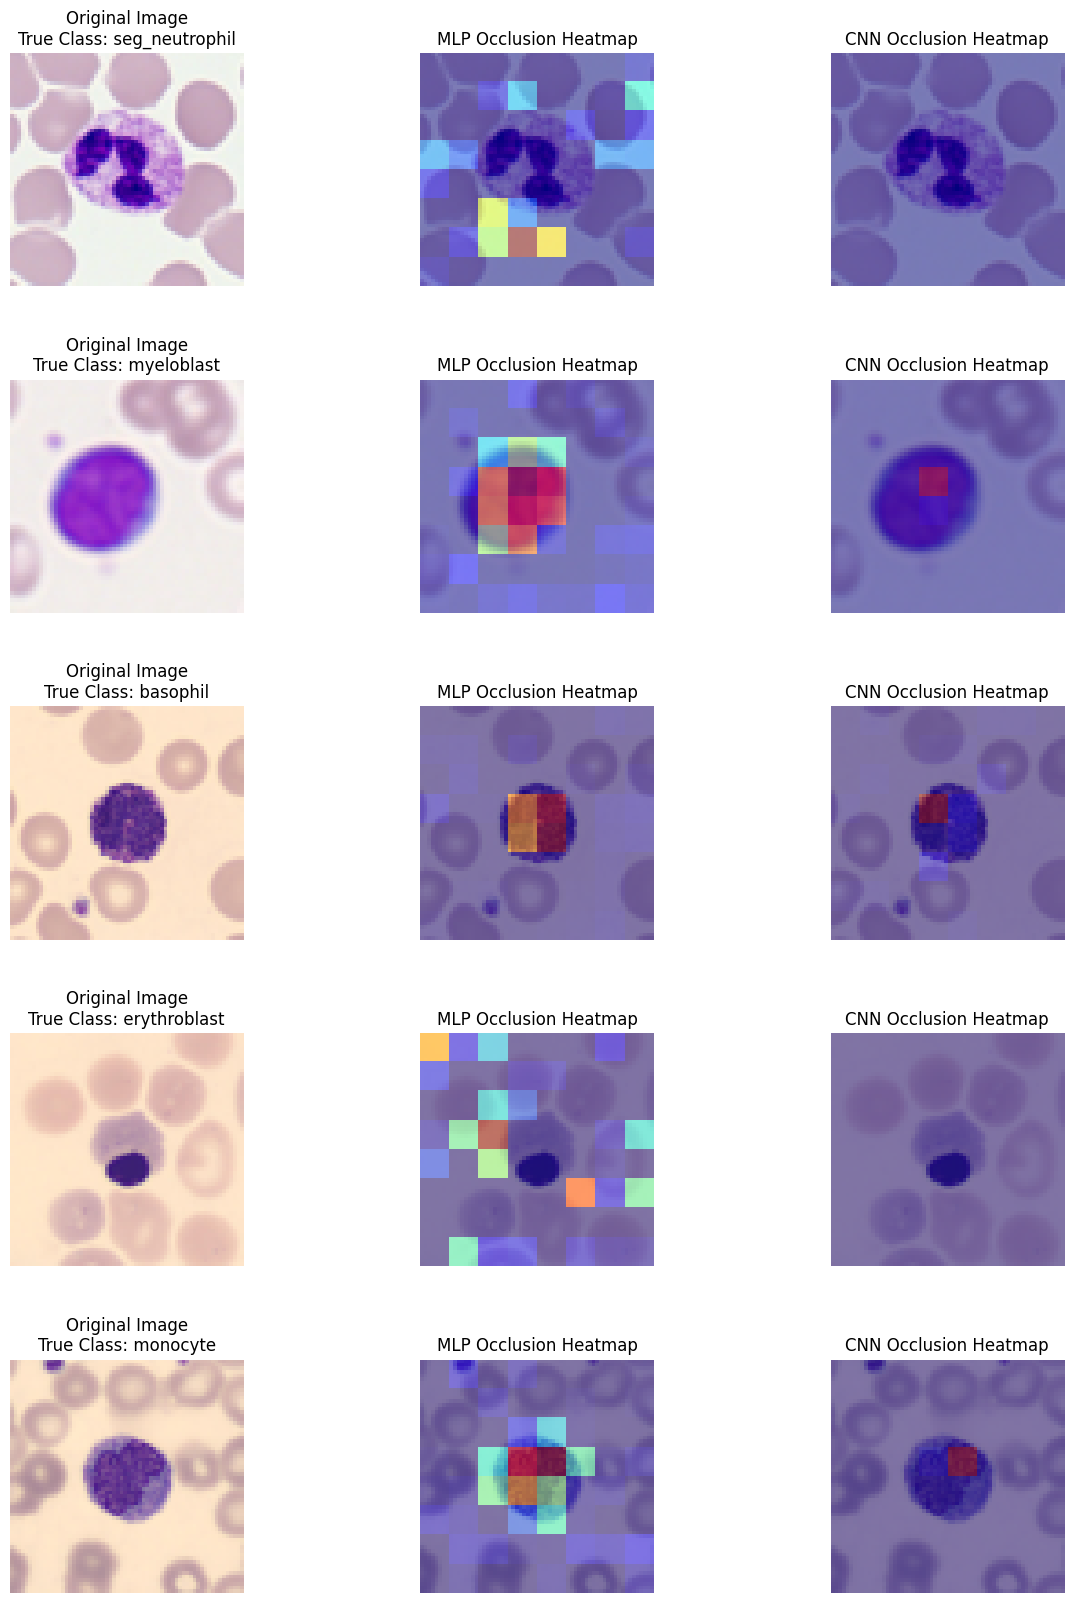

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
def compute_occlusion_heatmap(model, image, label, patch_size, device):
    model.eval()
    image = image.to(device)
    with torch.no_grad():
        orig_output = model(image)
        orig_prob = F.softmax(orig_output, dim=1)[0, label].item()
    _, c, h, w = image.shape
    heatmap = np.zeros((h, w))
    img_mean = image.mean(dim=[2, 3], keepdim=True)
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            masked_image = image.clone()
            masked_image[:, :, y:y+patch_size, x:x+patch_size] = img_mean
            with torch.no_grad():
                masked_output = model(masked_image)
                masked_prob = F.softmax(masked_output, dim=1)[0, label].item()
            drop = orig_prob - masked_prob
            heatmap[y:y+patch_size, x:x+patch_size] = max(0, drop)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max() 
    return heatmap
def visualize_occlusion_sensitivity(mlp_model, cnn_model, dataset, classes, device, patch_size=8, num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
    plt.subplots_adjust(hspace=0.4)
    selected_indices = []
    class_counts = {c: 0 for c in range(len(classes))}
    for i in range(len(dataset)):
        _, label = dataset[i]
        if class_counts[label] == 0:
            selected_indices.append(i)
            class_counts[label] = 1
        if len(selected_indices) == num_samples:
            break
    for idx, sample_idx in enumerate(selected_indices):
        image_tensor, label = dataset[sample_idx]
        image_batch = image_tensor.unsqueeze(0)
        img_vis = image_tensor.numpy().transpose((1, 2, 0))
        img_vis = img_vis * 0.5 + 0.5
        img_vis = np.clip(img_vis, 0, 1)
        mlp_heatmap = compute_occlusion_heatmap(mlp_model, image_batch, label, patch_size, device)
        cnn_heatmap = compute_occlusion_heatmap(cnn_model, image_batch, label, patch_size, device)
        axes[idx, 0].imshow(img_vis)
        axes[idx, 0].set_title(f"Original Image\nTrue Class: {classes[label]}")
        axes[idx, 0].axis('off')
        axes[idx, 1].imshow(img_vis)
        axes[idx, 1].imshow(mlp_heatmap, cmap='jet', alpha=0.5) 
        axes[idx, 1].set_title("MLP Occlusion Heatmap")
        axes[idx, 1].axis('off')
        axes[idx, 2].imshow(img_vis)
        axes[idx, 2].imshow(cnn_heatmap, cmap='jet', alpha=0.5) 
        axes[idx, 2].set_title("CNN Occlusion Heatmap")
        axes[idx, 2].axis('off')
    plt.show()
visualize_occlusion_sensitivity(model, cnn_model, test_dataset, train_dataset.dataset.classes, device, patch_size=8)
